# BLIP-2 + Flan-T5 LLM 사용 예제

BLIP-2(Bootstrapping Language-Image Pre-training 2)는 **frozen 비전 인코더**와 **frozen LLM**을
**Q-Former**라는 경량 브릿지로 연결한 비전-언어 모델입니다.
BLIP(02번 노트북)보다 적은 학습 데이터로도 더 풍부한 텍스트를 생성할 수 있습니다.

논문: https://arxiv.org/abs/2301.12597

> **중요**: `instructblip-flan-t5-xl`은 **질문·지시는 한국어 등 여러 언어로 입력**할 수 있지만,
> **응답은 항상 영어**로 생성됩니다. Flan-T5-XL은 텍스트 전용으로는 다국어 LLM이지만,
> InstructBLIP의 Q-Former·instruction tuning이 **영어 VQA/캡션 데이터**로 학습되었기 때문입니다.

이 노트북에서 다루는 내용:
1. BLIP-2 구조 이해 (ViT → Q-Former → Flan-T5)
2. **InstructBLIP-Flan-T5-XL** 모델 로드
3. **언어별 질문 → 영어 캡션** — 한국어·영어·일본어·중국어 프롬프트 비교
4. **언어별 VQA** — 여러 언어로 질문, 영어로 답변
5. **지시 따르기** — 한국어 지시 입력, 영어 응답
6. **배치 추론** — 여러 이미지를 한꺼번에 질의
7. **BLIP vs BLIP-2 vs LLaVA 비교 요약**

## 1. 환경 설정

터미널에서 의존성을 설치합니다.

```bash
pip install -r requirements.txt
```

```
torch>=2.0.0
torchvision>=0.15.0
transformers>=4.40.0
accelerate>=0.27.0
pillow>=10.0.0
matplotlib>=3.8.0
requests>=2.31.0
jupyter>=1.0.0
ipykernel>=6.29.0
```

> **GPU 메모리 안내**: `instructblip-flan-t5-xl`은 fp16 기준 약 **8~10GB VRAM**이 필요합니다.
> GPU가 없으면 CPU에서도 실행 가능하지만 매우 느립니다.
> 최초 실행 시 Hugging Face Hub에서 약 **16GB**를 다운로드합니다.

In [ ]:
# BLIP-2 GPU 로드(device_map="auto")에 필요 
# %pip install -q accelerate>=0.27.0

In [1]:
import torch
import requests
from dataclasses import dataclass
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from transformers import InstructBlipProcessor, InstructBlipForConditionalGeneration


def setup_korean_font():
    """matplotlib 한글 폰트 설정 (Windows/Mac/Linux)"""
    for font in ("Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans KR"):
        if font in {f.name for f in fm.fontManager.ttflist}:
            plt.rcParams["font.family"] = font
            break
    else:
        print("한글 폰트를 찾지 못했습니다. 제목 한글이 □로 표시될 수 있습니다.")
    plt.rcParams["axes.unicode_minus"] = False


setup_korean_font()

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32
print(f"사용 디바이스: {device}")
print(f"연산 dtype: {dtype}")
print(f"matplotlib 폰트: {plt.rcParams['font.family']}")

사용 디바이스: cuda
연산 dtype: torch.float16
matplotlib 폰트: ['Malgun Gothic']


## 2. BLIP-2 구조와 LLM 선택

```
이미지 → [ViT (frozen)] → [Q-Former (학습)] → [Flan-T5 (frozen LLM)] → 영어 텍스트
```

BLIP-2의 핵심은 **Q-Former**입니다. 비전 특징을 LLM이 이해할 수 있는 soft prompt로 변환한 뒤,
frozen LLM의 생성 능력을 그대로 활용합니다. Q-Former와 instruction tuning은 VQAv2·COCO 등
**영어** 데이터로 학습되므로, 한국어로 질문해도 **응답은 영어 COCO 스타일 캡션**으로 나옵니다.

| 모델 | LLM 백본 | 출력 언어 | 특징 |
|------|----------|----------|------|
| `Salesforce/blip2-opt-2.7b` | OPT-2.7B | 영어 | 가장 가벼운 BLIP-2 |
| `Salesforce/blip2-flan-t5-xl` | Flan-T5-XL | 영어 | 기본 캡셔닝·VQA |
| **`Salesforce/instructblip-flan-t5-xl`** | Flan-T5-XL | **영어** | **지시 따르기** (이 노트북 기본값) |
| `Salesforce/instructblip-vicuna-7b` | Vicuna-7B | 영어 | 고품질 대화, VRAM 14GB+ |

이 노트북은 **InstructBLIP + Flan-T5-XL** 조합을 사용합니다.
Flan-T5-XL은 텍스트 전용으로는 다국어 LLM이지만, InstructBLIP에서는 **입력(질문)만 다국어**이고
**출력(답변)은 영어**로 고정됩니다. 한국어 답변이 필요하면 별도 번역 모델을 붙이거나
Qwen2-VL 등 다국어 VLM을 사용해야 합니다.

In [2]:
MODEL_ID = "Salesforce/instructblip-flan-t5-xl"

load_kwargs = {
    "torch_dtype": dtype,
    "low_cpu_mem_usage": True,
}
if device == "cuda":
    load_kwargs["device_map"] = "auto"  # GPU 메모리에 맞게 자동 배치
else:
    load_kwargs["device_map"] = None

processor = InstructBlipProcessor.from_pretrained(MODEL_ID)
model = InstructBlipForConditionalGeneration.from_pretrained(MODEL_ID, **load_kwargs)
if device == "cpu":
    model = model.to(device)
model.eval()

print(f"모델 로드 완료: {MODEL_ID}")
print(f"모델 디바이스: {model.device}")

# PC에서 다운로드 약 22분 소요 (약 16GB)

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1363 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie language_model.shared.weight to language_model.lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


모델 로드 완료: Salesforce/instructblip-flan-t5-xl
모델 디바이스: cuda:0


## 3. 샘플 이미지 준비

[MS COCO](https://cocodataset.org/) val2017에서 **예제에 사용할 몇 장만** URL로 불러옵니다.
02·04번 노트북과 동일한 샘플을 사용해 결과를 비교할 수 있습니다.

- 이미지 URL: `http://images.cocodataset.org/val2017/{file_name}`
- 각 샘플에 COCO **참고 캡션** 포함 (생성 결과 비교용)

로컬 이미지를 쓰려면 `Image.open("경로/이미지.jpg")` 또는 `load_image_from_url("https://...")`를 사용하면 됩니다.

URL: http://images.cocodataset.org/val2017/000000543581.jpg
COCO image_id=543581, category=dog, size=(640, 427)
COCO 참고 캡션: A dog is sitting on the couch in a living room.


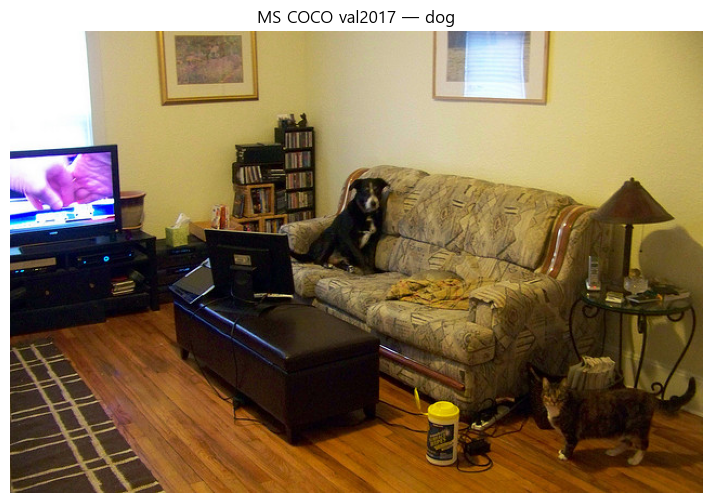

In [4]:
COCO_IMAGE_BASE = "http://images.cocodataset.org/val2017/"

# file_name: COCO val2017 파일명, captions: 사람이 작성한 참고 캡션
COCO_SAMPLE_URLS: dict[str, dict] = {
    "dog": {
        "file_name": "000000543581.jpg",
        "image_id": 543581,
        "captions": [
            "A dog is sitting on the couch in a living room.",
            "A cute black dog sitting on the couch.",
        ],
    },
    "cat": {
        "file_name": "000000039769.jpg",
        "image_id": 39769,
        "captions": [
            "There are two cats laying down with two remotes",
            "Two cats sleeping with a remote control near each of them.",
        ],
    },
    "car": {
        "file_name": "000000527220.jpg",
        "image_id": 527220,
        "captions": [
            "A red car next to a gas station sign and parked blue and silver motorcycles.",
            "A red car is parked next to motorcycles at a gas station.",
        ],
    },
    "person": {
        "file_name": "000000001761.jpg",
        "image_id": 1761,
        "captions": [
            "A person riding a motorcycle on a dirt road.",
            "A man riding on the back of a motorcycle.",
        ],
    },
}
COCO_SAMPLE_CATEGORIES = list(COCO_SAMPLE_URLS.keys())


@dataclass
class CocoSample:
    image: Image.Image
    url: str
    image_id: int
    category: str
    captions: list[str]


def load_image_from_url(url: str) -> Image.Image:
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    return Image.open(BytesIO(response.content)).convert("RGB")


def load_coco_sample_meta(category: str) -> CocoSample:
    if category not in COCO_SAMPLE_URLS:
        raise ValueError(
            f"등록되지 않은 카테고리 '{category}'. "
            f"사용 가능: {', '.join(COCO_SAMPLE_CATEGORIES)}"
        )
    meta = COCO_SAMPLE_URLS[category]
    url = COCO_IMAGE_BASE + meta["file_name"]
    image = load_image_from_url(url)
    return CocoSample(
        image=image,
        url=url,
        image_id=meta["image_id"],
        category=category,
        captions=meta["captions"],
    )


def load_coco_samples(categories: list[str]) -> list[CocoSample]:
    return [load_coco_sample_meta(cat) for cat in categories]


def show_image(image: Image.Image, title: str = ""):
    plt.figure(figsize=(10, 6))
    plt.imshow(image)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()


sample = load_coco_sample_meta("dog")
image = sample.image
print(f"URL: {sample.url}")
print(f"COCO image_id={sample.image_id}, category={sample.category}, size={image.size}")
print(f"COCO 참고 캡션: {sample.captions[0]}")
show_image(image, f"MS COCO val2017 — {sample.category}")

## 4. 추론 헬퍼 함수

InstructBLIP은 **이미지 + 텍스트 지시**를 입력으로 받아 Flan-T5가 답을 생성합니다.
질문·지시는 한국어 등 여러 언어로 작성할 수 있지만, **생성되는 답변은 영어**입니다.

In [5]:
def _move_inputs_to_model(inputs: dict) -> dict:
    """device_map='auto' 환경에서 입력 텐서를 모델과 같은 디바이스·dtype으로 이동"""
    model_device = model.device
    model_dtype = next(model.parameters()).dtype
    moved = {}
    for key, value in inputs.items():
        if isinstance(value, torch.Tensor):
            if value.is_floating_point():
                moved[key] = value.to(device=model_device, dtype=model_dtype)
            else:
                moved[key] = value.to(device=model_device)
        else:
            moved[key] = value
    return moved


def ask_blip2(
    img: Image.Image,
    prompt: str,
    max_new_tokens: int = 128,
) -> str:
    """InstructBLIP으로 이미지에 대한 질의·지시 수행 (응답은 영어)"""
    inputs = processor(images=img, text=prompt, return_tensors="pt")
    inputs = _move_inputs_to_model(inputs)
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens)
    return processor.decode(output_ids[0], skip_special_tokens=True).strip()


# 동작 확인 (응답은 영어)
test_answer = ask_blip2(image, "Briefly describe this image.", max_new_tokens=64)
print(f"테스트 응답 (영어): {test_answer}")

테스트 응답 (영어): a living room with a couch, tv, and a cat


## 5. 언어별 질문 → 영어 캡션

같은 이미지에 **언어별 지시**를 주어 캡션을 생성해 봅니다.
프롬프트 언어가 달라도 **응답은 모두 영어**로 나오는 것을 확인할 수 있습니다.

> **참고**: `"한국어로 설명해주세요"`처럼 출력 언어를 지정해도 영어로 답합니다.
> InstructBLIP은 영어 VQA/캡션 데이터로 학습되었기 때문입니다.

COCO 참고 캡션 (영어): A dog is sitting on the couch in a living room.

[질문: 한국어 질문] 이 사진을 한 문장으로 설명해주세요.
[응답: 영어]   a dog is sitting on a couch in a living room with a tv on it

[질문: English] Describe this image in one sentence.
[응답: 영어]   The image features a living room with a couch, a chair, and a television. The couch is positioned in the middle of the room, with the chair closer to the television. There are two dogs sitting on the couch, one of which is positioned on the right side of the room. The other dog is positioned on the left side of the room, closer to

[질문: 日本語] この画像を一文で説明してください。
[응답: 영어]   tv is fox sports 1

[질문: 中文] 请用一句话描述这张图片。
[응답: 영어]   yes



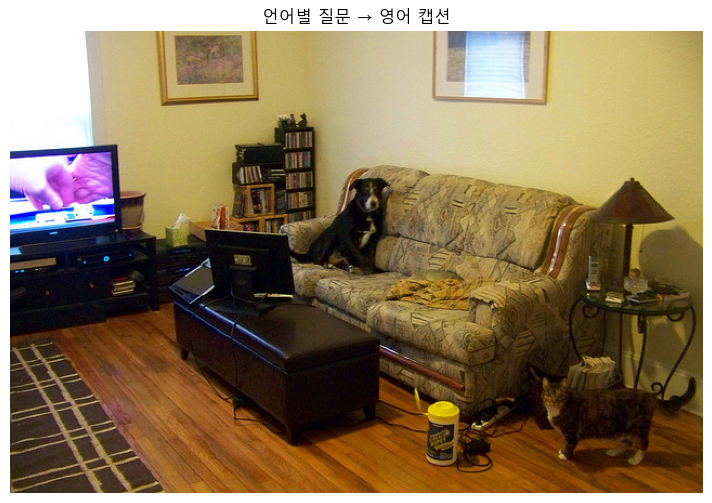

In [6]:
# 질문 언어별 프롬프트 — 출력 언어 지정을 포함해도 응답은 영어, 일본어/중국어는 잘 안됨.
CAPTION_PROMPTS = {
    "한국어 질문": "이 사진을 한 문장으로 설명해주세요.",
    "English": "Describe this image in one sentence.",
    "日本語": "この画像を一文で説明してください。",
    "中文": "请用一句话描述这张图片。",
}

print(f"COCO 참고 캡션 (영어): {sample.captions[0]}\n")
for lang, prompt in CAPTION_PROMPTS.items():
    caption = ask_blip2(image, prompt, max_new_tokens=80)
    print(f"[질문: {lang}] {prompt}")
    print(f"[응답: 영어]   {caption}\n")

show_image(image, "언어별 질문 → 영어 캡션")

## 6. 언어별 VQA (응답은 영어)

같은 내용을 여러 언어로 질문해 봅니다. 질문 언어와 관계없이 **답변은 영어**로 생성됩니다.

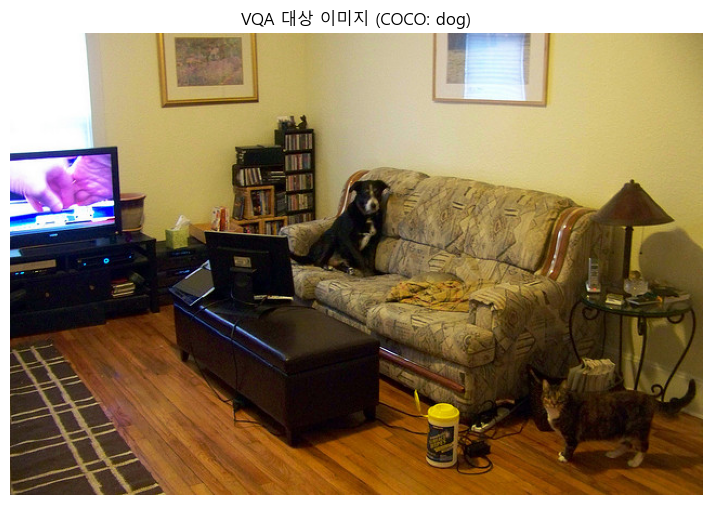

[질문: 한국어] 이 사진에 있는 동물은 무엇이고, 어디에 있나요?
[응답: 영어]   a tv is on in the living room with a tv commercial on it

[질문: English] What animal is in this photo and where is it?
[응답: 영어]   dog on couch

[질문: 日本語] この写真にはどんな動物がいて、どこにいますか？
[응답: 영어]   

[질문: 中文] 这张照片里有什么动物？它在哪里？
[응답: 영어]   tv



In [7]:
CROSS_LINGUAL_VQA = [
    ("한국어", "이 사진에 있는 동물은 무엇이고, 어디에 있나요?"),
    ("English", "What animal is in this photo and where is it?"),
    ("日本語", "この写真にはどんな動物がいて、どこにいますか？"),
    ("中文", "这张照片里有什么动物？它在哪里？"),
]

show_image(image, f"VQA 대상 이미지 (COCO: {sample.category})")
for lang, question in CROSS_LINGUAL_VQA:
    answer = ask_blip2(image, question, max_new_tokens=64)
    print(f"[질문: {lang}] {question}")
    print(f"[응답: 영어]   {answer}\n")

## 7. 지시 따르기 (Instruction Following)

InstructBLIP은 단순 캡션뿐 아니라 **구체적인 지시**에도 응답합니다.
지시는 한국어로 작성할 수 있지만, **응답은 영어**로 생성됩니다.

In [7]:
INSTRUCTIONS = [
    "이 사진에 보이는 물체를 나열하고, 각각의 색깔을 알려주세요.",
    "사진 속 동물의 자세와 주변 환경을 3문장 이상으로 자세히 설명해주세요.",
    "이 장면의 분위기를 한 단어로 표현하고, 그 이유를 설명해주세요.",
]

for i, instruction in enumerate(INSTRUCTIONS, 1):
    answer = ask_blip2(image, instruction, max_new_tokens=150)
    print(f"--- 지시 {i} (한국어) ---")
    print(f"지시: {instruction}")
    print(f"응답 (영어): {answer}\n")

--- 지시 1 (한국어) ---
지시: 이 사진에 보이는 물체를 나열하고, 각각의 색깔을 알려주세요.
응답 (영어): a dog is sitting on a couch in a living room with a tv on

--- 지시 2 (한국어) ---
지시: 사진 속 동물의 자세와 주변 환경을 3문장 이상으로 자세히 설명해주세요.
응답 (영어): a living room with a dog and cat sitting on a couch and a tv

--- 지시 3 (한국어) ---
지시: 이 장면의 분위기를 한 단어로 표현하고, 그 이유를 설명해주세요.
응답 (영어): a dog is sitting on a couch in a living room with a tv on



## 8. 배치 추론 — 여러 이미지 한꺼번에 질의

여러 COCO 샘플에 동일한 한국어 질문을 적용합니다. 응답은 모두 **영어**로 생성됩니다.

[dog] 질문 (한국어): 이 사진의 주요 피사체를 한 문장으로 설명해주세요.
[dog] 응답 (영어): a dog is sitting on a couch in a living room with a tv on
[dog] COCO 참고:   A dog is sitting on the couch in a living room.

[cat] 질문 (한국어): 이 사진의 주요 피사체를 한 문장으로 설명해주세요.
[cat] 응답 (영어): two cats are sleeping on a pink blanket with remotes on them
[cat] COCO 참고:   There are two cats laying down with two remotes

[car] 질문 (한국어): 이 사진의 주요 피사체를 한 문장으로 설명해주세요.
[car] 응답 (영어): a red car is parked next to a scooter at a gas station with a hess gas sign
[car] COCO 참고:   A red car next to a gas station sign and parked blue and silver motorcycles.

[person] 질문 (한국어): 이 사진의 주요 피사체를 한 문장으로 설명해주세요.
[person] 응답 (영어): two planes are flying over a bridge and are marked with the number aaa
[person] COCO 참고:   A person riding a motorcycle on a dirt road.



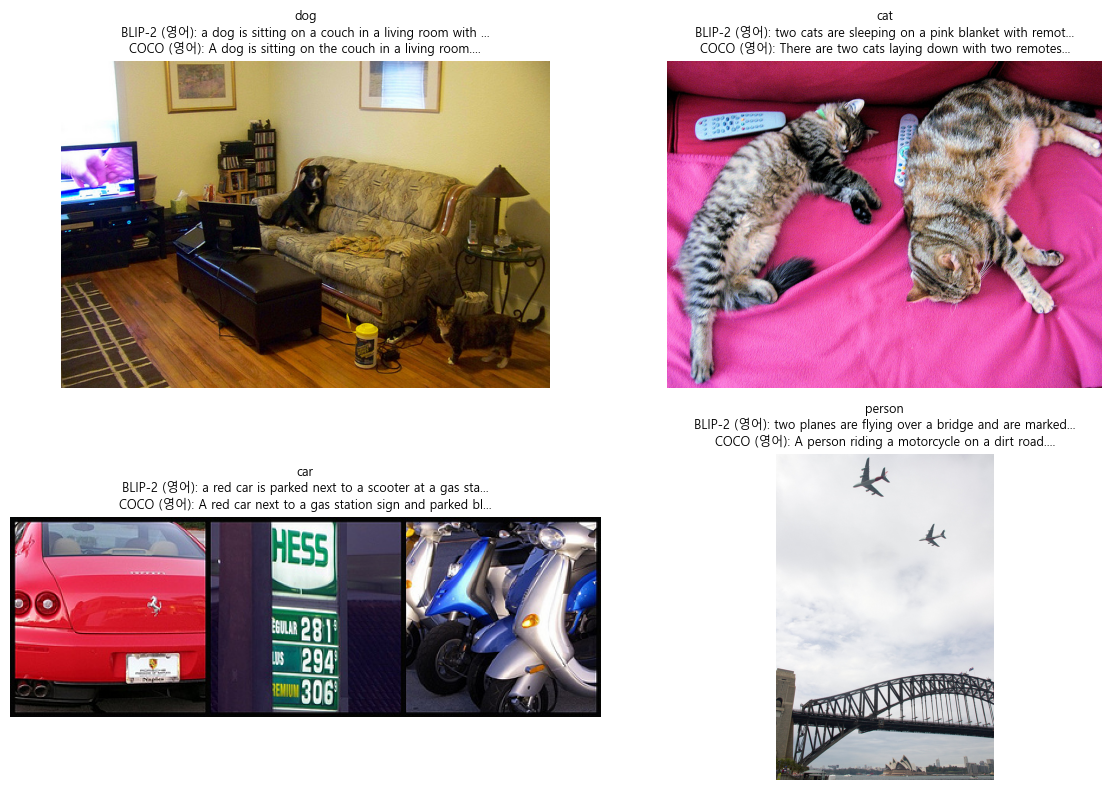

In [8]:
BATCH_PROMPT = "이 사진의 주요 피사체를 한 문장으로 설명해주세요."
batch_samples = load_coco_samples(["dog", "cat", "car", "person"])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, coco_sample in zip(axes.flat, batch_samples):
    answer = ask_blip2(coco_sample.image, BATCH_PROMPT, max_new_tokens=80)
    gt = coco_sample.captions[0]
    ax.imshow(coco_sample.image)
    ax.axis("off")
    ax.set_title(
        f"{coco_sample.category}\nBLIP-2 (영어): {answer[:50]}...\nCOCO (영어): {gt[:50]}...",
        fontsize=9,
    )
    print(f"[{coco_sample.category}] 질문 (한국어): {BATCH_PROMPT}")
    print(f"[{coco_sample.category}] 응답 (영어): {answer}")
    print(f"[{coco_sample.category}] COCO 참고:   {gt}\n")
plt.tight_layout()
plt.show()

## 9. 질문 언어 vs 응답 언어

InstructBLIP-Flan-T5-XL의 언어 동작을 정리하면 다음과 같습니다.

| | 지원 여부 | 설명 |
|---|----------|------|
| **질문·지시 (입력)** | ✓ 다국어 | 한국어·일본어·중국어 등으로 질문 가능 |
| **답변 (출력)** | ✗ 영어만 | `"한국어로 답해주세요"` 지정해도 영어로 생성 |

**한국어 답변이 필요할 때의 대안**

| 방법 | 설명 |
|------|------|
| **2단계 번역** | InstructBLIP → 영어 답변 → NLLB/MarianMT 등으로 한국어 번역 |
| **다국어 VLM 사용** | Qwen2-VL, InternVL2 등 한국어 출력을 지원하는 모델 |
| **파인튜닝** | 한국어 이미지-텍스트 데이터로 Q-Former 조정 (비용 큼) |

아래 코드는 **출력 언어 지정이 통하지 않음**을 확인하는 실험입니다.

In [ ]:
# 출력 언어 지정 시도 — 모두 영어로만 응답됨
QUESTION = "What is the main subject of this image?"

prompts = {
    "영어 질문": QUESTION,
    "영어 + 한국어 출력 지시": f"{QUESTION} Answer in Korean.",
    "한국어 질문": "이 사진의 주요 피사체는 무엇인가요?",
    "한국어 + 출력 언어 지시": "한국어로 답변해주세요. 이 사진의 주요 피사체는 무엇인가요?",
}

for label, prompt in prompts.items():
    answer = ask_blip2(image, prompt, max_new_tokens=64)
    print(f"[{label}]")
    print(f"  프롬프트: {prompt}")
    print(f"  응답 (영어): {answer}\n")

[영어 질문]
  프롬프트: What is the main subject of this image?
  응답 (영어): The main subject of the image is a living room with a couch, a cat, and a television.

[영어 + 한국어 출력 지시]
  프롬프트: What is the main subject of this image? Answer in Korean.
  응답 (영어): dog

[한국어 질문]
  프롬프트: 이 사진의 주요 피사체는 무엇인가요?
  응답 (영어): a tv is on in the living room with a tv commercial on it

[한국어 + 출력 언어 지시]
  프롬프트: 한국어로 답변해주세요. 이 사진의 주요 피사체는 무엇인가요?
  응답 (영어): 



## 10. BLIP vs BLIP-2 vs LLaVA 비교 요약

| 항목 | BLIP (02번) | BLIP-2 (이 노트북) | LLaVA (04번) |
|------|-------------|-------------------|--------------|
| **핵심 구조** | ViT + BERT 디코더 | ViT + Q-Former + frozen LLM | CLIP-ViT + Vicuna LLM |
| **LLM 백본** | BERT (소형) | Flan-T5-XL | Vicuna-7B |
| **질문 언어** | △ (영어 중심) | ✓ (다국어 입력 가능) | △ (영어 중심) |
| **응답 언어** | 영어 | **영어** | 영어 |
| **모델 크기** | ~990M (base) | ~4B (instructblip-flan-t5-xl) | ~7B |
| **VRAM** | ~2GB | ~8~10GB (fp16) | ~14GB (fp16) |
| **대화** | 단일 턴 Q→A | 단일 턴 지시·VQA | 다중 턴 맥락 유지 |
| **적합 용도** | 빠른 캡션·ITM·VQA | 영어 캡션·지시 따르기 | 복잡한 추론·대화형 AI |

**선택 가이드**
- 빠르고 가벼운 **캡션·매칭** → BLIP (`02_blip_image_captioning.ipynb`)
- **한국어 질문 + 영어 답변** VQA → BLIP-2 + Flan-T5 (이 노트북)
- **한국어 답변**이 필요 → 별도 번역 파이프라인 또는 Qwen2-VL 등 다국어 VLM
- **복잡한 추론·다중 턴 대화** → LLaVA (`04_llava_example.ipynb`)
- **분류·검색·유사도** → CLIP (`01_clip_example.ipynb`)